# Demo for Word2Vec model

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from save_load import load_model

## Loading model

In [9]:
MODEL_PATH = "models/model1.npz" 
vocab, params = load_model(MODEL_PATH)

print(f"Loaded Vocabulary Size: {len(vocab):,}")
print(f"Embedding Dimensions: {params.W_center.shape[1]}")

Loaded model from models/model1.npz
Loaded Vocabulary Size: 253,854
Embedding Dimensions: 300


## Testing similarity relationship

In [10]:
def get_most_similar(query_word: str, vocab, params, top_n: int = 5):
    """Finds the most similar words using cosine similarity"""
    if query_word not in vocab.token_to_idx:
        return f"'{query_word}' is not in the vocabulary."
    
    query_idx = vocab.token_to_idx[query_word]
    query_vec = params.W_center[query_idx]
    
    norms = np.linalg.norm(params.W_center, axis=1, keepdims=True) + 1e-9
    normalized_matrix = params.W_center / norms
    normalized_query = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    
    similarities = normalized_matrix @ normalized_query
    
    similarities[query_idx] = -np.inf 
    top_indices = np.argsort(similarities)[-top_n:][::-1]
    
    print(f"Most similar to '{query_word}':")
    for i in top_indices:
        print(f"  - {vocab.tokens[i]}: {similarities[i]:.4f}")
        

In [11]:
get_most_similar("france", vocab, params, top_n=5)
print("-" * 30)
get_most_similar("horse", vocab, params, top_n=5)
print("-" * 30)
get_most_similar("einstein", vocab, params, top_n=5)

Most similar to 'france':
  - vichy: 0.5484
  - french: 0.5381
  - pleven: 0.5337
  - gaulle: 0.5333
  - namur: 0.5238
------------------------------
Most similar to 'horse':
  - horses: 0.6871
  - pony: 0.5555
  - warmblood: 0.5456
  - thoroughbred: 0.5455
  - bred: 0.5356
------------------------------
Most similar to 'einstein':
  - relativity: 0.6777
  - bose: 0.6221
  - mileva: 0.6193
  - spacetime: 0.6098
  - electrodynamics: 0.5942


## Visualizing embedding space with the help of PCA

In [12]:
def plot_word_clusters(words: list, vocab, params):
    """Reduces embeddings to 2D using PCA and plots them to show semantic clustering"""
    vectors = []
    valid_words = []
    
    for word in words:
        if word in vocab.token_to_idx:
            idx = vocab.token_to_idx[word]
            vectors.append(params.W_center[idx])
            valid_words.append(word)
        else:
            print(f"Skipping '{word}' (OOV)")
            
    vectors = np.array(vectors)
    
    # PCA 300D to 2D
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)
    
    plt.figure(figsize=(10, 8))
    plt.style.use('ggplot')
    
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='coral', edgecolors='k', s=70)
    
    for i, word in enumerate(valid_words):
        plt.annotate(
            word, 
            xy=(vectors_2d[i, 0], vectors_2d[i, 1]), 
            xytext=(5, 5), 
            textcoords='offset points',
            fontsize=12
        )
        
    plt.title("2D PCA Projection of Word Embeddings", fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

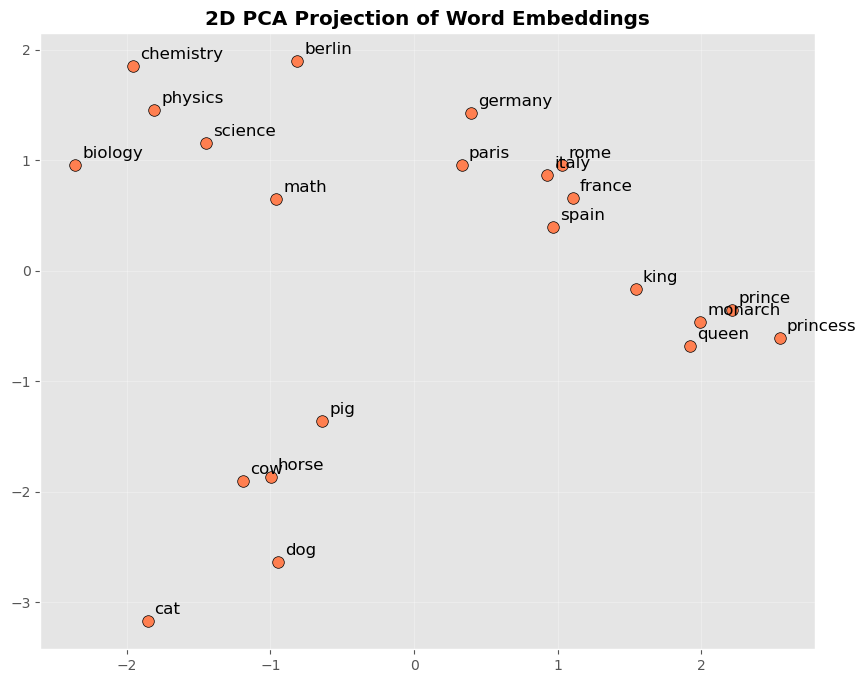

In [13]:
test_words = [
    "france", "germany", "italy", "spain", "paris", "berlin", "rome",
    "king", "queen", "prince", "princess", "monarch",                 
    "physics", "chemistry", "biology", "science", "math",        
    "dog", "cat", "horse", "cow", "pig"                           
]

plot_word_clusters(test_words, vocab, params)